# 02 · A Travel Agent

> Workshop module. Comes right after 01 (agents). A small, real app built from the *simple* agent you
> just learned - no new concepts, just useful tools.

We build **Wanderlust**, a travel-planning agent: `create_agent` (model + tools + loop) given four real
tools. There is **no memory yet** - every question is independent. Adding memory is exactly what the
**checkpointer** lesson does next.

In this notebook we will:
1. look at each tool and **which API it calls**,
2. **test every tool on its own** by passing parameters,
3. build the agent and **watch it decide** which tools to use, with a cleanly formatted trace,
4. run the **full flow** end to end.

The same code packaged as a CLI is in `travel_agent/` (`python travel_agent/cli.py`).

## 0 · Setup

In [16]:
import os, sys
# --- Load API keys from the project .env, no matter how/where Jupyter was started ---
_ENV_PATH = "/Users/datasense/Desktop/langgrapgh-agent/.env"
for _line in open(_ENV_PATH):
    _line = _line.strip()
    if _line and not _line.startswith("#") and "=" in _line:
        _k, _v = _line.split("=", 1)
        os.environ[_k.strip()] = _v.strip().strip('"').strip("'")
print("Loaded keys:", [k for k in ("OPENAI_API_KEY", "TAVILY_API_KEY", "SERPAPI_API_KEY") if os.getenv(k)])

# tools + agent live in the travel_agent/ project folder
sys.path.append("travel_agent")

import time
from IPython.display import Image, Markdown, display

def _mermaid_png(mermaid_text, attempts=5):
    "Render mermaid text to PNG via the mermaid.ink API, retrying transient failures."
    from langchain_core.runnables.graph_mermaid import draw_mermaid_png
    last = None
    for i in range(attempts):
        try:
            return draw_mermaid_png(mermaid_text)
        except Exception as e:
            last = e
            time.sleep(1.5 * (i + 1))
    raise last

def show(graph):
    "Render a compiled LangGraph as an inline mermaid PNG (ASCII fallback if the API is down)."
    try:
        display(Image(_mermaid_png(graph.get_graph().draw_mermaid())))
    except Exception:
        print(graph.get_graph().draw_ascii())

def render_mermaid(mermaid_text):
    "Render any mermaid diagram string as an inline PNG."
    display(Image(_mermaid_png(mermaid_text)))

print("setup done")

Loaded keys: ['OPENAI_API_KEY', 'TAVILY_API_KEY', 'SERPAPI_API_KEY']
setup done


## 1 · The four tools and the APIs behind them

The agent's power comes from its tools. Each tool is a Python function that calls a real API:

| tool | calls | needs a key? |
|------|-------|--------------|
| `get_weather`    | **Open-Meteo** (geocoding + forecast) | no (free) |
| `web_search`     | **Tavily** search API | `TAVILY_API_KEY` |
| `search_flights` | **SerpApi** - Google Flights engine | `SERPAPI_API_KEY` |
| `search_hotels`  | **SerpApi** - Google Hotels engine | `SERPAPI_API_KEY` |

Visually, the agent sits in the middle and reaches out to these services:

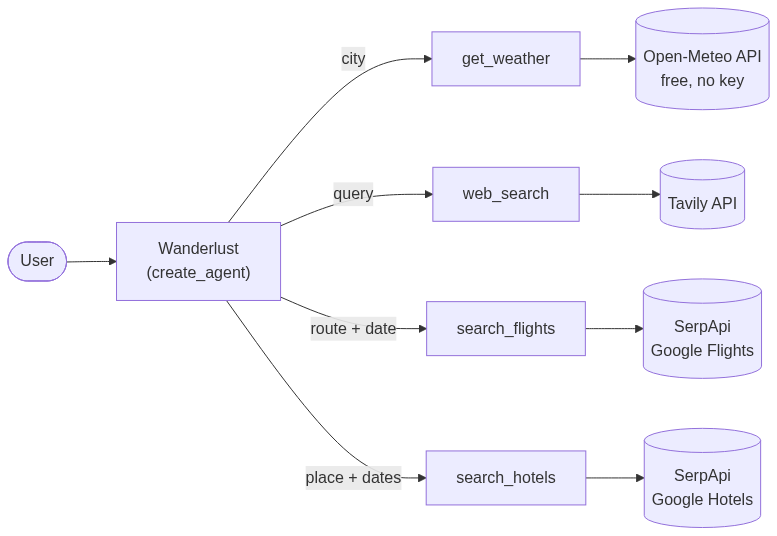

In [17]:
render_mermaid('''
graph LR
    U([User]) --> A["Wanderlust<br/>(create_agent)"]
    A -->|city| W[get_weather]
    A -->|query| S[web_search]
    A -->|route + date| F[search_flights]
    A -->|place + dates| H[search_hotels]
    W --> WA[("Open-Meteo API<br/>free, no key")]
    S --> SA[("Tavily API")]
    F --> FA[("SerpApi<br/>Google Flights")]
    H --> HA[("SerpApi<br/>Google Hotels")]
''')

## 2 · Test each tool on its own

Before wiring them into an agent, let's call each tool directly with explicit parameters, so we know
exactly what the model will get back. (A `@tool` is still a normal callable - use `.invoke({...})`.)

**2a · `get_weather`** - calls **Open-Meteo** (no key). First it geocodes the city name to
latitude/longitude, then asks for the daily forecast.

In [18]:
from tools import get_weather, web_search, search_flights, search_hotels

print(get_weather.invoke({"city": "Delhi", "days": 3}))

Weather for Delhi, India (next 3 day(s)):
  2026-05-30: 25-35C, rain chance 67%
  2026-05-31: 24-35C, rain chance 47%
  2026-06-01: 25-37C, rain chance 18%


**2b · `web_search`** - calls the **Tavily** search API and returns the top results as text.

In [19]:
print(web_search.invoke({"query": "best vegetarian restaurants in Kyoto"})[:600])

Top results for 'best vegetarian restaurants in Kyoto':
- Best Vegetarian Restaurants in Kyoto for Seasonal Japanese Cuisine: Kyoto’s rich culinary heritage goes beyond wagyu and kaiseki, it’s also the best city to try exceptional vegetarian food. ## Kyoto by the MICHELIN Guide. This guide highlights restaurants with menus s (https://guide.michelin.com/us/en/article/travel/best-vegetarian-restaurants-in-kyoto-for-seasonal-japanese-cuisine)
- Nice vegetarian-friendly restaurant in Kyoto, Japan - Reddit: For high-end vegetarian cuisine in Kyoto, you're talking about Shojin Ryori , and the standa


**2c · `search_flights`** - calls **SerpApi's Google Flights** engine. Pass IATA airport codes and
a `YYYY-MM-DD` date.

In [20]:
print(search_flights.invoke({
    "origin": "JFK",
    "destination": "CDG",
    "outbound_date": "2026-07-10",
}))

Flights JFK -> CDG on 2026-07-10:
  $394 | Air France | 0 stop(s) | 7h10m
  $394 | American | 0 stop(s) | 7h35m
  $394 | JetBlue | 0 stop(s) | 7h41m
  $394 | Delta | 0 stop(s) | 7h45m


**2d · `search_hotels`** - calls **SerpApi's Google Hotels** engine. Pass a place and check-in /
check-out dates.

In [21]:
print(search_hotels.invoke({
    "location": "Paris",
    "check_in_date": "2026-07-10",
    "check_out_date": "2026-07-13",
}))

Hotels in Paris (2026-07-10 to 2026-07-13):
  Pullman Paris Tour Eiffel | $407/night | rating 4.6 | 4-star tourist hotel
  The Hoxton, Paris | $426/night | rating 4.4 | 4-star tourist hotel
  Maison Nabis by HappyCulture | $178/night | rating 4.7 | 4-star tourist hotel
  Hôtel Villa Saxe Eiffel | $225/night | rating 4.5 | 4-star tourist hotel


## 3 · Build the agent

Same simple agent as notebook 01: a model, the tools, a system prompt. `create_agent` builds the
`model <-> tools` loop. We import the exact agent the project uses (`travel_agent/agent.py`).

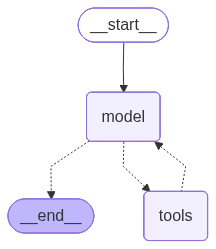

In [ ]:
from agent import build_agent

agent = build_agent()
show(agent)

It is the loop from notebook 01: `__start__ -> model -> (tools -> model)* -> __end__`.

## 4 · Watch the agent decide (formatted trace)

Now the interesting part: *we* don't choose the tools - the **model** does. This helper streams the run
and prints a clean, readable trace so you can see each decision:

- **bold labels** mark what the agent is *doing* (deciding, calling a tool, answering),
- tool results are shown in monospace,
- the final answer is rendered as Markdown (so the model's own bold/headers show through).

In [23]:
from langchain.messages import HumanMessage

def run_pretty(agent, query):
    "Stream a run and render a formatted, easy-to-follow trace."
    display(Markdown(f"> **You:** {query}"))
    for chunk in agent.stream({"messages": [HumanMessage(query)]}, stream_mode="updates"):
        for node, update in chunk.items():
            msg = update["messages"][-1]
            tool_calls = getattr(msg, "tool_calls", None)
            if tool_calls:
                for tc in tool_calls:
                    display(Markdown(
                        f"**Agent decides to call:** `{tc['name']}`  \n"
                        f"**arguments:** `{tc['args']}`"
                    ))
            elif msg.type == "tool":
                preview = msg.content if len(msg.content) < 350 else msg.content[:350] + " ..."
                display(Markdown(f"**Tool `{msg.name}` returned:**\n\n```\n{preview}\n```"))
            elif msg.content:
                display(Markdown(f"**Wanderlust:**\n\n{msg.content}"))

run_pretty(agent, "What's the weather in Lisbon for the next 3 days, and one great seafood spot?")

> **You:** What's the weather in Lisbon for the next 3 days, and one great seafood spot?

**Agent decides to call:** `get_weather`  
**arguments:** `{'city': 'Lisbon', 'days': 3}`

**Agent decides to call:** `web_search`  
**arguments:** `{'query': 'best seafood restaurants in Lisbon'}`

**Tool `get_weather` returned:**

```
Weather for Lisbon, Portugal (next 3 day(s)):
  2026-05-30: 18-27C, rain chance 0%
  2026-05-31: 18-28C, rain chance 0%
  2026-06-01: 18-25C, rain chance 0%
```

**Tool `web_search` returned:**

```
Top results for 'best seafood restaurants in Lisbon':
- Hi! What is the best seafood restaurant in Lisbon - Facebook: Marisqueira do Lis: Just a few meters from Ramiro, this is usually a good option with no waiting line. It offers delicious seafood, fast service (https://www.facebook.com/groups/2097230730468344/posts/2774190596105684)
- Cervejeria  ...
```

**Wanderlust:**

**Weather in Lisbon for the Next 3 Days:**
- **May 30, 2026:** 18-27°C, rain chance 0%
- **May 31, 2026:** 18-28°C, rain chance 0%
- **June 1, 2026:** 18-25°C, rain chance 0%

**Great Seafood Spot:**
Check out **Cervejaria Ramiro**! It's a must-visit for seafood lovers in Lisbon, known for its incredible seafood dishes and vibrant atmosphere. Enjoy your meal! 🦐🍽️

See how the agent *chose* `get_weather` and `web_search` on its own, read the results, then wrote
the answer. We never told it which tools to use.

## 5 · Full flow - a complete trip

One question that needs **all the moving parts**: flights, hotels, and weather. Watch the agent select
several tools in sequence and combine the results.

In [15]:
run_pretty(
    agent,
    "I want to fly JFK to CDG on 2026-07-10 and stay 3 nights in Paris. "
    "Find flights, hotels, and tell me the weather."
)

> **You:** I want to fly JFK to CDG on 2026-07-10 and stay 3 nights in Paris. Find flights, hotels, and tell me the weather.

**Agent decides to call:** `search_flights`  
**arguments:** `{'origin': 'JFK', 'destination': 'CDG', 'outbound_date': '2026-07-10'}`

**Agent decides to call:** `search_hotels`  
**arguments:** `{'location': 'Paris', 'check_in_date': '2026-07-10', 'check_out_date': '2026-07-13'}`

**Agent decides to call:** `get_weather`  
**arguments:** `{'city': 'Paris', 'days': 3}`

**Tool `search_flights` returned:**

```
Flights JFK -> CDG on 2026-07-10:
  $394 | Air France | 0 stop(s) | 7h10m
  $394 | American | 0 stop(s) | 7h35m
  $394 | JetBlue | 0 stop(s) | 7h41m
  $394 | Delta | 0 stop(s) | 7h45m
```

**Tool `search_hotels` returned:**

```
Hotels in Paris (2026-07-10 to 2026-07-13):
  Pullman Paris Tour Eiffel | $410/night | rating 4.6 | 4-star tourist hotel
  Hôtel Château Frontenac | $368/night | rating 4.4 | 4-star tourist hotel
  The Hoxton, Paris | $434/night | rating 4.4 | 4-star tourist hotel
  Hôtel Villa Saxe Eiffel | $234/night | rating 4.5 | 4-star tourist hotel
```

**Tool `get_weather` returned:**

```
Weather for Paris, France (next 3 day(s)):
  2026-05-30: 21-33C, rain chance 10%
  2026-05-31: 16-25C, rain chance 18%
  2026-06-01: 14-24C, rain chance 11%
```

**Wanderlust:**

Here's your travel info for your trip from JFK to Paris (CDG) on July 10, 2026:

### Flights
- **Air France**: $394 | 0 stops | 7h 10m
- **American Airlines**: $394 | 0 stops | 7h 35m
- **JetBlue**: $394 | 0 stops | 7h 41m
- **Delta**: $394 | 0 stops | 7h 45m

### Hotels in Paris (July 10-13, 2026)
1. **Pullman Paris Tour Eiffel**: $410/night | Rating: 4.6
2. **Hôtel Château Frontenac**: $368/night | Rating: 4.4
3. **The Hoxton, Paris**: $434/night | Rating: 4.4
4. **Hôtel Villa Saxe Eiffel**: $234/night | Rating: 4.5

### Weather for Paris (July 10-13, 2026)
- **July 10**: 21-33°C, rain chance 10%
- **July 11**: 16-25°C, rain chance 18%
- **July 12**: 14-24°C, rain chance 11%

Let me know if you need any further assistance or booking!

## Recap

- Four tools, each calling a real API (Open-Meteo, Tavily, SerpApi x2).
- We tested every tool on its own by passing parameters.
- `create_agent` turns the model + tools into an agent that **decides** which tools to call.
- The formatted trace makes the agent's reasoning visible: decide -> call -> observe -> answer.

### What's missing? Memory.
Ask a follow-up like *"make it cheaper"* and the agent won't remember the trip - each call is
independent. That's the motivation for the **checkpointer** lesson (coming up).

### Next: the same tools, served over an **MCP server**
Right now the tools live *inside* our Python process. In the next notebook we move them out to a
standalone **MCP server** (FastMCP) and have the agent load them over the network - same agent, same
behaviour, decoupled tools.

### Exercises
1. Add a `currency_convert` tool and have the agent budget the trip.
2. Add a 4th destination question and watch which tools it picks.
3. Change the system prompt to make Wanderlust a luxury-only concierge.